# Test 1 on Qiskit Metal

Qiskit metal is a Q-EDA tool developped by IBM on Python platform. 
It is a good reference to design very own Q-EDA software.

## Note on installation

Qiskit metal is on process of developping. Therefore, it's necessary to clone
its repository to install.

After first clone, we navigate into its folder and run the following scripts
to install

```bash
conda env create -n <env_name> -f environment.yml
conda activate <env_name>
python -m pip install --no-deps -e .
```

To update metal, we should first pull latest source from Github.com and then
run the following scripts inside its folder

```bash
conda env update -n <env_name_exist> -f environment.yml
conda activate <env_name_exist>
python -m pip install --no-deps -e .
```

**Note** that the instructions on Qiskit Metal website missed the "-f" flag
in conda command.

## Import and first try

In [1]:
import qiskit_metal as metal

%metal_heading Welcome to Qiskit Metal!
print(f'Import Qiskit Metal V{metal.__version__}')


Import Qiskit Metal V0.1.5


In [2]:
def refresh_metal_gui(gui: metal.MetalGUI, shot_name: str = 'shot'):
    gui.rebuild()
    gui.autoscale()
    shot_name = str(shot_name)
    if len(shot_name) > 0:
        gui.screenshot(name=shot_name)

print(f'Prepare function to refresh metal GUI {refresh_metal_gui}')


Prepare function to refresh metal GUI <function refresh_metal_gui at 0x0000020BFBEE3430>


In [3]:
print('Create a new design')
design = metal.designs.DesignPlanar()
design.variables['cpw_width'] = '15 um'
design.variables['cpw_gap'] = '9 um'
print(design)


Create a new design


In [4]:
print('Create GUI window')
gui = metal.MetalGUI(design)


Create GUI window


In [5]:
print(f'Import a simple transmon')
from qiskit_metal.qlibrary.qubits.Transmon_Interdigitated import TransmonInterdigitated
TransmonInterdigitated.get_template_options(design)


Import a simple transmon


{'pos_x': '0.0um',
 'pos_y': '0.0um',
 'orientation': '0.0',
 'chip': 'main',
 'layer': '1',
 'pad_width': '1000um',
 'pad_height': '300um',
 'finger_width': '50um',
 'finger_height': '100um',
 'finger_space': '50um',
 'pad_pos_x': '0um',
 'pad_pos_y': '0um',
 'comb_width': '50um',
 'comb_space_vert': '50um',
 'comb_space_hor': '50um',
 'jj_width': '20um',
 'cc_space': '50um',
 'cc_width': '100um',
 'cc_height': '100um',
 'cc_topleft_space': '50um',
 'cc_topleft_width': '100um',
 'cc_topleft_height': '100um',
 'cc_topright_space': '50um',
 'cc_topright_width': '100um',
 'cc_topright_height': '100um',
 'rotation_top_pad': '180',
 'inductor_width': '20um'}

In [6]:
print(f'Import CPW link between qubits')
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
RouteMeander.get_template_options(design)


Import CPW link between qubits


{'chip': 'main',
 'layer': '1',
 'pin_inputs': {'start_pin': {'component': '', 'pin': ''},
  'end_pin': {'component': '', 'pin': ''}},
 'fillet': '0',
 'lead': {'start_straight': '0mm',
  'end_straight': '0mm',
  'start_jogged_extension': '',
  'end_jogged_extension': ''},
 'total_length': '7mm',
 'trace_width': 'cpw_width',
 'meander': {'spacing': '200um', 'asymmetry': '0um'},
 'snap': 'true',
 'prevent_short_edges': 'true',
 'hfss_wire_bonds': False,
 'q3d_wire_bonds': False,
 'aedt_q3d_wire_bonds': False,
 'aedt_hfss_wire_bonds': False}

In [7]:
def simple_example_of_metal(design: metal.designs.DesignPlanar):
    design.overwrite_enabled = True
    q1 = TransmonInterdigitated(design, 'qubit1', options=dict(pos_x='-2.0mm',orientation='-90'))
    q2 = TransmonInterdigitated(design, 'qubit2', options=dict(pos_x='2.0mm', orientation='90'))
    cpw12 = RouteMeander(design, options=metal.Dict(
        total_length= '8mm',
        pin_inputs=metal.Dict(
            start_pin=metal.Dict(
                component= 'qubit1',
                pin= 'bus2'),
            end_pin=metal.Dict(
                component= 'qubit2',
                pin= 'bus1')),
        lead=metal.Dict(
            start_straight='0.5mm',
            end_straight='0.5mm'),
        meander=metal.Dict(
            asymmetry='0mm'),
        fillet='90um',
    ))


Simple example with two qubits and their CPW link


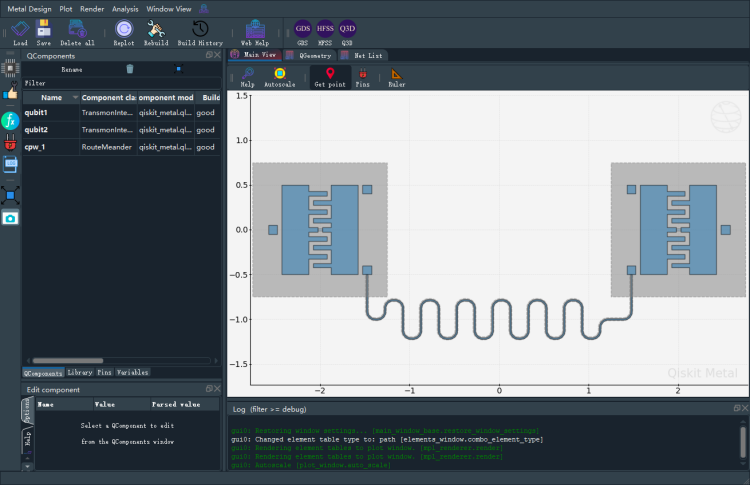

In [8]:
print('Simple example with two qubits and their CPW link')
simple_example_of_metal(design)
refresh_metal_gui(gui, '02_metal_test01_simple')


## Complex example

Make a complex example with 4 qubits, their links and 4 pads.

In [9]:
print(f'Import another Transmon')
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket
TransmonPocket.get_template_options(design)


Import another Transmon


{'pos_x': '0.0um',
 'pos_y': '0.0um',
 'orientation': '0.0',
 'chip': 'main',
 'layer': '1',
 'connection_pads': {},
 '_default_connection_pads': {'pad_gap': '15um',
  'pad_width': '125um',
  'pad_height': '30um',
  'pad_cpw_shift': '5um',
  'pad_cpw_extent': '25um',
  'cpw_width': 'cpw_width',
  'cpw_gap': 'cpw_gap',
  'cpw_extend': '100um',
  'pocket_extent': '5um',
  'pocket_rise': '65um',
  'loc_W': '+1',
  'loc_H': '+1'},
 'pad_gap': '30um',
 'inductor_width': '20um',
 'pad_width': '455um',
 'pad_height': '90um',
 'pocket_width': '650um',
 'pocket_height': '650um',
 'hfss_wire_bonds': False,
 'q3d_wire_bonds': False,
 'aedt_q3d_wire_bonds': False,
 'aedt_hfss_wire_bonds': False,
 'hfss_inductance': '10nH',
 'hfss_capacitance': 0,
 'hfss_resistance': 0,
 'hfss_mesh_kw_jj': 7e-06,
 'q3d_inductance': '10nH',
 'q3d_capacitance': 0,
 'q3d_resistance': 0,
 'q3d_mesh_kw_jj': 7e-06,
 'gds_cell_name': 'my_other_junction',
 'aedt_q3d_inductance': 1e-08,
 'aedt_q3d_capacitance': 0,
 'aedt_hf

In [10]:
def complex_example_of_metal(design: metal.designs.DesignPlanar) -> tuple[tuple[TransmonPocket], tuple[RouteMeander]]:
    # Allow running the same cell here multiple times to overwrite changes
    design.overwrite_enabled = True

    ## Custom options for all the transmons
    options = dict(
        # Some options we want to modify from the defaults
        # (see below for defaults)
        pad_width = '425 um',
        pocket_height = '650um',
        # Adding 4 connectors (see below for defaults)
        connection_pads=dict(
            readout = dict(loc_W=+1,loc_H=-1, pad_width='200um'),
            bus1 = dict(loc_W=-1,loc_H=+1, pad_height='30um'),
            bus2 = dict(loc_W=-1,loc_H=-1, pad_height='50um')
        )
    )

    ## Create 4 transmons
    q1 = TransmonPocket(design, 'Q1', options = dict(
        pos_x='+2.42251mm', pos_y='+0.0mm', **options))
    q2 = TransmonPocket(design, 'Q2', options = dict(
        pos_x='+0.0mm', pos_y='-1.2mm', orientation = '270', **options))
    q3 = TransmonPocket(design, 'Q3', options = dict(
        pos_x='-2.42251mm', pos_y='+0.0mm', orientation = '180', **options))
    q4 = TransmonPocket(design, 'Q4', options = dict(
        pos_x='+0.0mm', pos_y='+1.2mm', orientation = '90', **options))

    ## Basic link options
    link_options = metal.Dict(
        lead=metal.Dict(
            start_straight='0.2mm',
            end_straight='0.2mm'),
        trace_gap='9um',
        trace_width='15um')

    ## Function to connect two qubits
    def connect(link_name: str, qubit1: str, pin1: str, qubit2: str, pin2: str,
            length: str, asymmetry='0 um', flip=False, fillet='90um'):
        """Connect two pins with a CPW."""
        myoptions = metal.Dict(
            fillet=fillet,
            hfss_wire_bonds = True,
            pin_inputs=metal.Dict(
                start_pin=metal.Dict(
                    component=qubit1,
                    pin=pin1),
                end_pin=metal.Dict(
                    component=qubit2,
                    pin=pin2)),
            total_length=length)
        myoptions.update(link_options)
        myoptions.meander.asymmetry = asymmetry
        myoptions.meander.lead_direction_inverted = 'true' if flip else 'false'
        return RouteMeander(design, link_name, myoptions)

    ## Build Create 4 links
    asym = 140
    cpw1 = connect('cpw1', 'Q1', 'bus2', 'Q2', 'bus1', '5.8 mm', f'+{asym}um')
    cpw2 = connect('cpw2', 'Q3', 'bus1', 'Q2', 'bus2', '5.8 mm', f'-{asym}um', flip=True)
    cpw3 = connect('cpw3', 'Q3', 'bus2', 'Q4', 'bus1', '5.8 mm', f'+{asym}um')
    cpw4 = connect('cpw4', 'Q1', 'bus1', 'Q4', 'bus2', '5.8 mm', f'-{asym}um', flip=True)

    ## Return all qubits and links
    return (q1, q2, q3, q4), (cpw1, cpw2, cpw3, cpw4)


11:43AM 10s CRITICAL [_qt_message_handler]: line: 0, func: None(), file: None  CRITICAL: OleSetClipboard: Failed to set mime data (application/x-qt-image) on clipboard: COM error 0xffffffff800401d0  (Unknown error 0x0800401d0) (参数错误。)



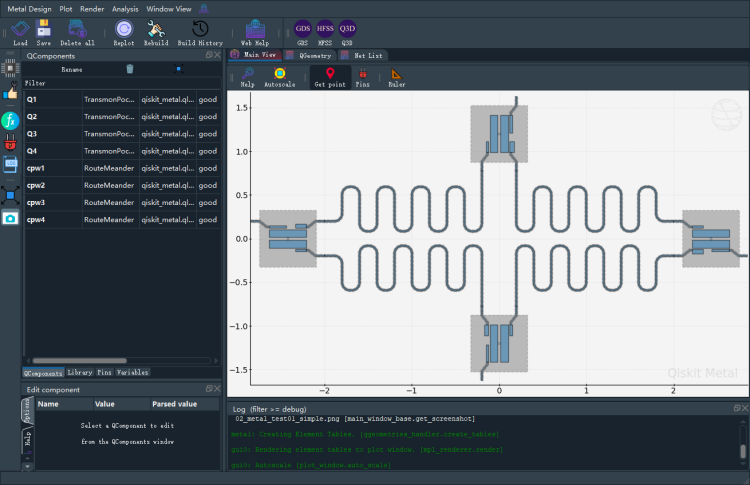

In [11]:
design.delete_all_components()
qubits, cpws = complex_example_of_metal(design)
refresh_metal_gui(gui, '02_metal_test01_complex')


In [12]:
design.save_design('02-metal-test01.py')
gui.main_window.setWindowModified(False)
gui.main_window.close()


11:43AM 10s WARNING [save_design]: Saving is a beta feature.
11:43AM 10s INFO [save_design]: Saving design to 02-metal-test01.py
11:43AM 10s WARNING [find_id]: In Components.find_id(), the name=__getstate__ is not used in design._components
11:43AM 11s ERROR [log_error_easy]: 

Traceback (most recent call last):

  File "c:\workspace\triq\qiskit-metal\qiskit_metal\toolbox_metal\import_export.py", line 51, in save_metal
    pickle.dump(self, open(filename, "wb"))

TypeError: 'NoneType' object is not callable

ERROR WHILE SAVING: 'NoneType' object is not callable
11:43AM 11s ERROR [save_design]: Saving failed.


True